In [377]:
import os
import pandas as pd

# please Define the path to the extracted CSV files in the  folder
data_folder = "/Users/krishianjanlanka/Downloads/data_5drivers"

# Check if the folder exists
if not os.path.exists(data_folder):
    raise FileNotFoundError(f"The folder {data_folder} does not exist. Please check the path.")

# Lists all CSV files in the folder
all_files = []
for root, dirs, files in os.walk(data_folder):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            all_files.append(file_path)

# Checking if any CSV files were found
if len(all_files) == 0:
    raise ValueError(f"No CSV files found in the folder: {data_folder}. Please check the folder contents.")

# i want Combine all CSV files into a single DataFrame
dataframes = []
for file_path in all_files:
    try:
        df = pd.read_csv(file_path)
        dataframes.append(df)
    except pd.errors.EmptyDataError:
        print(f"Warning: {file_path} is empty or corrupted and will be skipped.")

# Concatenate all dataframes into one
if len(dataframes) > 0:
    data = pd.concat(dataframes, ignore_index=True)
else:
    raise ValueError("No valid CSV files were loaded. All files might be empty or corrupted.")

# Dataset Insights
print("Dataset Loaded Successfully")
print(f"Dataset Shape: {data.shape}")
print(f"Data Columns: {data.columns.tolist()}")
print(f"Data Sample:\n{data.head()}")

# Check for missing values
missing_values = data.isnull().sum()
print(f"Missing Values:\n{missing_values[missing_values > 0]}")

# Data Types
print(f"Data Types:\n{data.dtypes}")

# Data Summary
print("\nData Summary:")
print(data.describe(include='all'))

# Additional Preprocessing Steps
# Convert 'time' column to datetime
data['time'] = pd.to_datetime(data['time'], errors='coerce')

# Check for rows where time conversion failed
invalid_time = data[data['time'].isna()]
if not invalid_time.empty:
    print(f"Invalid Time Entries:\n{invalid_time}")

# Convert 'status' to categorical type
data['status'] = data['status'].astype('category')

# Optional: Sort data by time
data.sort_values(by='time', inplace=True)

# Final insights
print("\nFinal Data Insights after Preprocessing:")
print(f"Final Dataset Shape: {data.shape}")
print(f"Final Data Types:\n{data.dtypes}")
print(f"Data Sample After Preprocessing:\n{data.head()}")


/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/3697042019.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(dataframes, ignore_index=True)


Dataset Loaded Successfully
Dataset Shape: (4187013, 5)
Data Columns: ['plate', 'longitude', 'latitude', 'time', 'status']
Data Sample:
  plate   longitude   latitude                 time  status
0     1  114.111015  22.541567  2016-08-07 00:00:03     1.0
1     2  114.100769  22.546417  2016-08-07 00:00:03     0.0
2     0  114.108749  22.537701  2016-08-07 00:00:08     1.0
3     4  114.201385  22.649300  2016-08-07 00:00:10     0.0
4     1  114.110985  22.542017  2016-08-07 00:00:16     1.0
Missing Values:
Series([], dtype: int64)
Data Types:
plate         object
longitude    float64
latitude     float64
time          object
status       float64
dtype: object

Data Summary:
            plate     longitude      latitude                 time  \
count   4187013.0  4.187013e+06  4.187013e+06              4187013   
unique        5.0           NaN           NaN              3676604   
top           0.0           NaN           NaN  2016-08-20 08:09:46   
freq    1014370.0           NaN      

In [12]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 32.9 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nipype 1.8.6 requires networkx>=2.0, which is not installed.
Note: you may need to restart the kernel to use updated packages.


In [381]:
import pandas as pd


# 1. Convert `plate` to a categorical type
df['plate'] = df['plate'].astype('category')

# 2. Check for invalid longitude and latitude values
df = df[(df['longitude'] >= -180) & (df['longitude'] <= 180)]
df = df[(df['latitude'] >= -90) & (df['latitude'] <= 90)]

# 3. Convert `time` to datetime (already done in your output)
df['time'] = pd.to_datetime(df['time'])

# 4. Check and handle anomalies in `status`
# Ensure the status is either 0 or 1 and convert it to category
df = df[df['status'].isin([0, 1])]
df['status'] = df['status'].astype('category')

# 5. Remove duplicate entries (if any)
df = df.drop_duplicates(subset=['plate', 'longitude', 'latitude', 'time'])


# Final dataset information
print(f"Final Dataset Shape: {df.shape}")
print(f"Missing Values After Cleaning: {df.isnull().sum()}")
print(f"Final Data Types: \n{df.dtypes}")
print(f"Sample of Cleaned Data:\n{df.sample(5)}")


Final Dataset Shape: (26039, 5)
Missing Values After Cleaning: plate        0
longitude    0
latitude     0
time         0
status       0
dtype: int64
Final Data Types: 
plate              category
longitude           float64
latitude            float64
time         datetime64[ns]
status             category
dtype: object
Sample of Cleaned Data:
      plate   longitude   latitude                time status
16510     3  114.139252  22.546600 2016-08-22 15:38:27      0
7038      1  114.067352  22.528749 2016-08-22 06:50:47      0
17321     3  114.156883  22.560850 2016-08-22 16:18:06      1
19512     1  114.040497  22.522350 2016-08-22 18:41:55      0
14132     1  114.054733  22.518217 2016-08-22 13:11:18      0


In [36]:

# Ensure the 'time' column is properly converted to datetime
data_cleaned.loc[:, 'time'] = pd.to_datetime(data_cleaned['time'], errors='coerce')

# Extract time-related features (hour, day_of_week, month) using .loc to avoid warnings
data_cleaned.loc[:, 'hour'] = data_cleaned['time'].dt.hour
data_cleaned.loc[:, 'day_of_week'] = data_cleaned['time'].dt.dayofweek
data_cleaned.loc[:, 'month'] = data_cleaned['time'].dt.month



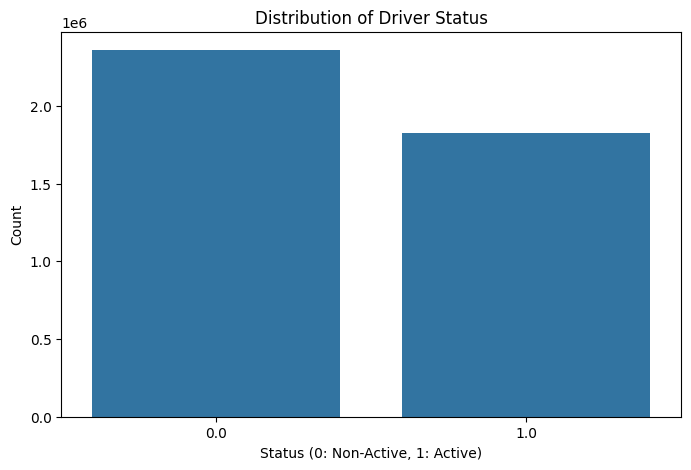

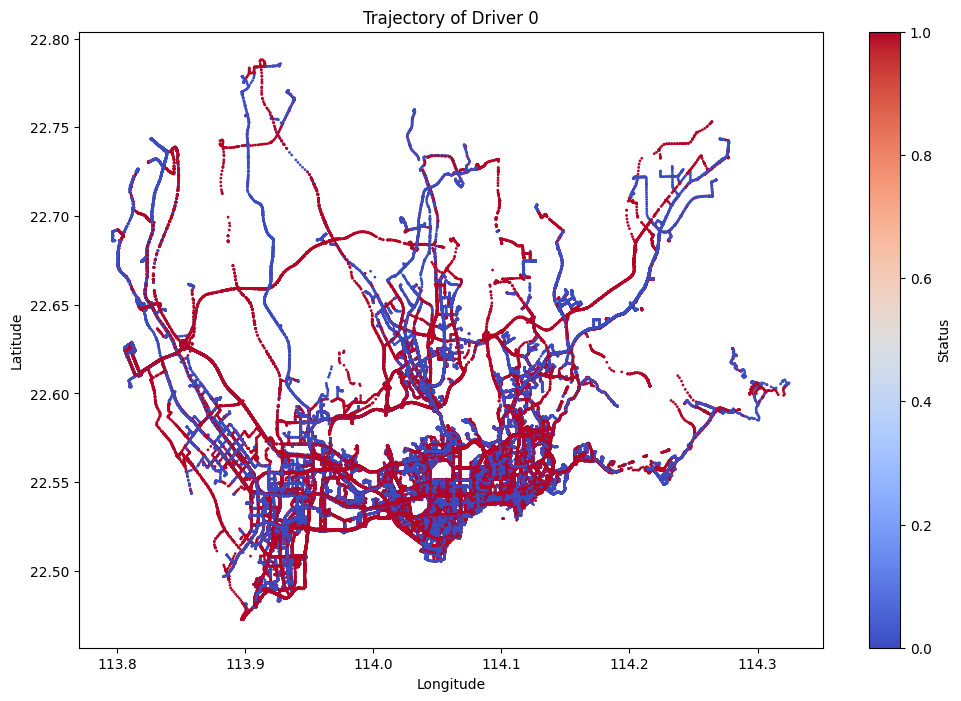

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of the 'status' variable
plt.figure(figsize=(8, 5))
sns.countplot(x='status', data=data)
plt.title('Distribution of Driver Status')
plt.xlabel('Status (0: Non-Active, 1: Active)')
plt.ylabel('Count')
plt.show()

# Plotting trajectories of the first driver
driver_id = 0  # Change this to visualize other drivers
driver_data = data[data['plate'] == driver_id]

plt.figure(figsize=(12, 8))
plt.scatter(driver_data['longitude'], driver_data['latitude'], c=driver_data['status'], cmap='coolwarm', s=1)
plt.colorbar(label='Status')
plt.title(f'Trajectory of Driver {driver_id}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


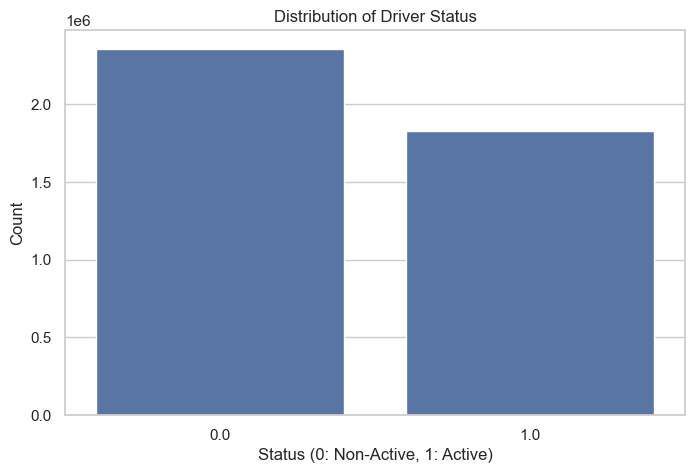

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetics for the plots
sns.set(style="whitegrid")

# Visualize the distribution of the 'status' variable
plt.figure(figsize=(8, 5))
sns.countplot(x='status', data=data)
plt.title('Distribution of Driver Status')
plt.xlabel('Status (0: Non-Active, 1: Active)')
plt.ylabel('Count')
plt.show()


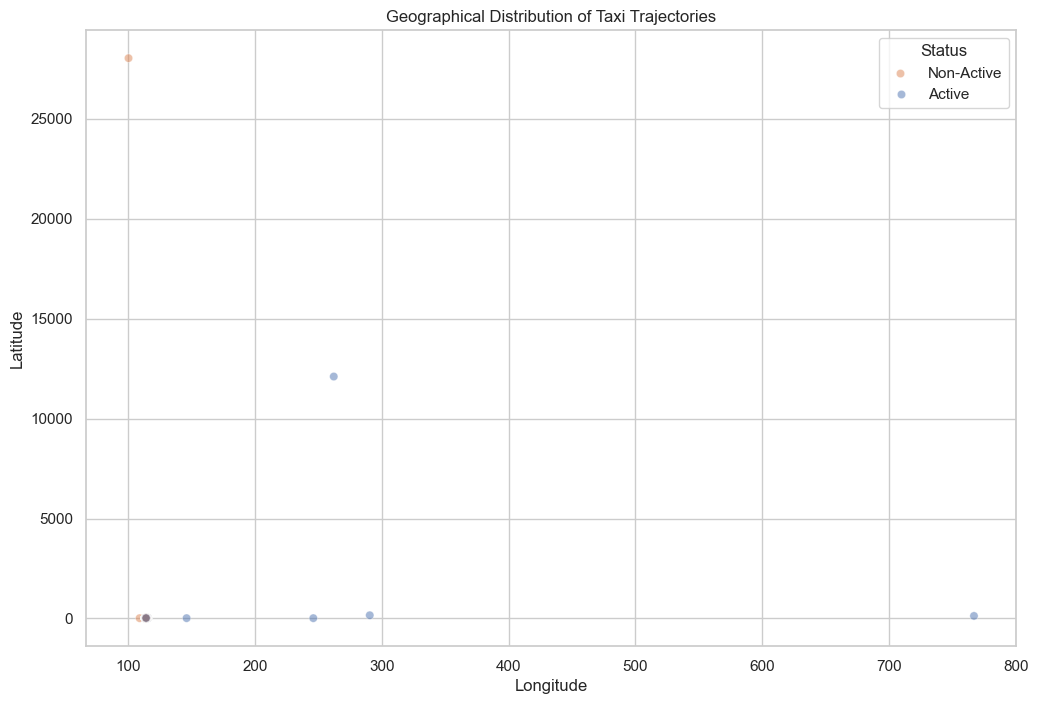

In [18]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='longitude', y='latitude', hue='status', data=data, alpha=0.5)
plt.title('Geographical Distribution of Taxi Trajectories')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Status', loc='upper right', labels=['Non-Active', 'Active'])
plt.show()


/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_2700/834333512.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=data, palette='viridis')


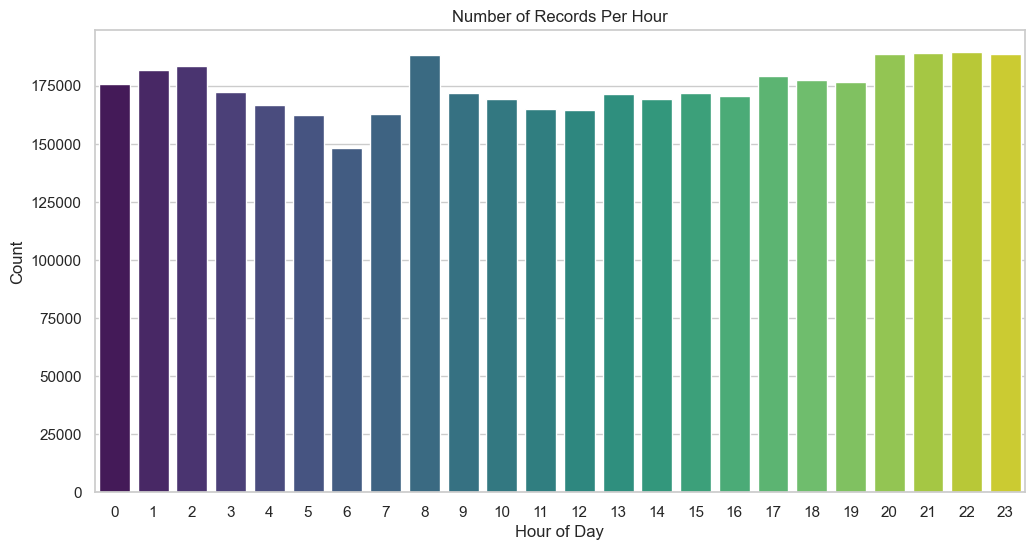

In [19]:
# Convert 'time' to datetime
data['time'] = pd.to_datetime(data['time'])

# Extract date features
data['date'] = data['time'].dt.date
data['hour'] = data['time'].dt.hour

# Plotting the number of records per hour
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=data, palette='viridis')
plt.title('Number of Records Per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()


In [26]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [26]:
# Check for invalid latitude values
invalid_latitude = data[(data['latitude'] < -90) | (data['latitude'] > 90)]

# Check for invalid longitude values
invalid_longitude = data[(data['longitude'] < -180) | (data['longitude'] > 180)]

# Print the number of invalid entries
print(f"Invalid Latitude Entries: {len(invalid_latitude)}")
print(f"Invalid Longitude Entries: {len(invalid_longitude)}")


Invalid Latitude Entries: 4
Invalid Longitude Entries: 4


In [28]:
# Drop rows with invalid latitude or longitude
data_cleaned = data[(data['latitude'] >= -90) & (data['latitude'] <= 90) &
                     (data['longitude'] >= -180) & (data['longitude'] <= 180)]

# Print the shape of the cleaned dataset
print(f"Original Dataset Shape: {data.shape}")
print(f"Cleaned Dataset Shape: {data_cleaned.shape}")


Original Dataset Shape: (4187013, 5)
Cleaned Dataset Shape: (4187008, 5)


In [383]:
import pandas as pd
import os
from geopy.distance import great_circle


folder_path = '/Users/krishianjanlanka/Downloads/data_5drivers/'

# Created an empty list to hold DataFrames
dataframes = []

# Loop through all CSV files in the specified directory
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        # Load each CSV file
        df = pd.read_csv(file_path)
        # Append the DataFrame to the list
        dataframes.append(df)

# Concatenate all DataFrames into one
data = pd.concat(dataframes, ignore_index=True)

# Check the initial shape of the concatenated dataset
print(f"Dataset Loaded Successfully")
print(f"Dataset Shape: {data.shape}")
print(f"Data Columns: {data.columns.tolist()}")

# Check for invalid latitude and longitude values
invalid_latitude = data[(data['latitude'] < -90) | (data['latitude'] > 90)]
invalid_longitude = data[(data['longitude'] < -180) | (data['longitude'] > 180)]

# Print the number of invalid entries
print(f"Invalid Latitude Entries: {len(invalid_latitude)}")
print(f"Invalid Longitude Entries: {len(invalid_longitude)}")

# Drop rows with invalid latitude or longitude
data_cleaned = data[(data['latitude'] >= -90) & (data['latitude'] <= 90) &
                     (data['longitude'] >= -180) & (data['longitude'] <= 180)]

# Reset the index of the cleaned DataFrame
data_cleaned.reset_index(drop=True, inplace=True)

# Print the shape of the cleaned dataset
print(f"Original Dataset Shape: {data.shape}")
print(f"Cleaned Dataset Shape: {data_cleaned.shape}")

# Function to calculate distance between consecutive points
def calculate_distance(row):
    if row.name == 0:  # First row has no previous point to compare to
        return 0
    else:
        try:
            prev_point = (data_cleaned.iloc[row.name - 1]['latitude'], data_cleaned.iloc[row.name - 1]['longitude'])
            current_point = (row['latitude'], row['longitude'])
            return great_circle(prev_point, current_point).meters
        except IndexError as e:
            print(f"IndexError encountered: {e}")
            return 0  # Return 0 if there's an index error

# Calculate distance
data_cleaned['distance'] = data_cleaned.apply(calculate_distance, axis=1)

# Convert time to datetime
data_cleaned['time'] = pd.to_datetime(data_cleaned['time'])

# Calculate time difference in seconds
data_cleaned['time_diff'] = data_cleaned['time'].diff().dt.total_seconds().fillna(0)

# Calculate speed in meters per second
data_cleaned['speed'] = data_cleaned['distance'] / data_cleaned['time_diff'].replace(0, pd.NA)

# Check the first few rows of the cleaned dataset
print(data_cleaned.head())

# Print final insights
print(f"Final Data Insights:")
print(f"Final Dataset Shape: {data_cleaned.shape}")
print(f"Final Data Types:\n{data_cleaned.dtypes}")


/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/1134750676.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(dataframes, ignore_index=True)


Dataset Loaded Successfully
Dataset Shape: (4187013, 5)
Data Columns: ['plate', 'longitude', 'latitude', 'time', 'status']
Invalid Latitude Entries: 4
Invalid Longitude Entries: 4
Original Dataset Shape: (4187013, 5)
Cleaned Dataset Shape: (4187008, 5)


/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/1134750676.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['distance'] = data_cleaned.apply(calculate_distance, axis=1)
/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/1134750676.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['time'] = pd.to_datetime(data_cleaned['time'])
/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/1134750676.py:67: SettingWithCopyWarning: 
A value is t

  plate   longitude   latitude                time  status      distance  \
0     1  114.111015  22.541567 2016-08-07 00:00:03     1.0      0.000000   
1     2  114.100769  22.546417 2016-08-07 00:00:03     0.0   1182.396129   
2     0  114.108749  22.537701 2016-08-07 00:00:08     1.0   1269.233304   
3     4  114.201385  22.649300 2016-08-07 00:00:10     0.0  15634.330088   
4     1  114.110985  22.542017 2016-08-07 00:00:16     1.0  15114.087152   

   time_diff        speed  
0        0.0         <NA>  
1        0.0         <NA>  
2        5.0   253.846661  
3        2.0  7817.165044  
4        6.0  2519.014525  
Final Data Insights:
Final Dataset Shape: (4187008, 8)
Final Data Types:
plate                object
longitude           float64
latitude            float64
time         datetime64[ns]
status              float64
distance            float64
time_diff           float64
speed                object
dtype: object


/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/1134750676.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['speed'] = data_cleaned['distance'] / data_cleaned['time_diff'].replace(0, pd.NA)


In [397]:
missing_values = data_cleaned.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)


Missing Values in Each Column:
plate          0
longitude      0
latitude       0
time           0
status         0
distance       0
time_diff      1
speed          0
hour           0
day_of_week    0
month          0
dtype: int64


In [51]:
print("Descriptive Statistics:")
print(data_cleaned.describe())
print("Data Types:")
print(data_cleaned.dtypes)


Descriptive Statistics:
          longitude      latitude                           time  \
count  4.187008e+06  4.187008e+06                        4187008   
mean   1.140468e+02  2.258584e+01  2016-09-23 19:48:40.978721280   
min    1.090125e+02  1.600280e+01            2016-07-01 00:00:03   
25%    1.140031e+02  2.253388e+01  2016-08-08 18:48:30.750000128   
50%    1.140562e+02  2.254647e+01            2016-09-17 15:06:55   
75%    1.141083e+02  2.256358e+01  2016-11-09 14:56:02.249999872   
max    1.460661e+02  2.686990e+01            2016-12-26 23:59:56   
std    9.418809e-02  3.576127e-01                            NaN   

             status      distance     time_diff         speed          hour  \
count  4.187008e+06  4.187008e+06  4.187008e+06  4.187008e+06  4.187008e+06   
mean   4.366488e-01  1.661176e+04  3.301627e-01  4.636933e+03  1.167533e+01   
min    0.000000e+00  0.000000e+00 -9.676792e+06 -4.857263e+05  0.000000e+00   
25%    0.000000e+00  3.523164e+03  1.000000e+00

In [393]:
# Handle missing values in speed column
#  Fill missing values with the mean (or median) of the speed column
mean_speed = data_cleaned['speed'].mean()
data_cleaned.loc[:, 'speed'] = data_cleaned['speed'].fillna(mean_speed)

#  Drop rows with missing values in the speed column
# data_cleaned = data_cleaned.dropna(subset=['speed'])

# Check for any remaining NaN values
print("Missing Values in Speed Column:", data_cleaned['speed'].isnull().sum())

# Fix time_diff calculation using .loc
data_cleaned.loc[:, 'time_diff'] = data_cleaned['time'].diff().dt.total_seconds()

# Check the final dataset after updates
print("Final Dataset Shape:", data_cleaned.shape)
print("Data Types:\n", data_cleaned.dtypes)
print("Missing Values:\n", data_cleaned.isnull().sum())


/var/folders/bp/brqc8c_n71ddmt7rb4pbwb340000gn/T/ipykernel_18679/1680419411.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_cleaned.loc[:, 'speed'] = data_cleaned['speed'].fillna(mean_speed)


Missing Values in Speed Column: 0
Final Dataset Shape: (4187008, 8)
Data Types:
 plate                object
longitude           float64
latitude            float64
time         datetime64[ns]
status              float64
distance            float64
time_diff           float64
speed                object
dtype: object
Missing Values:
 plate        0
longitude    0
latitude     0
time         0
status       0
distance     0
time_diff    1
speed        0
dtype: int64


In [373]:
# Calculate speed in meters per second, avoiding SettingWithCopyWarning
data_cleaned = data_cleaned.copy()  # Make a copy to avoid chained assignment

# Calculate speed, replacing 0 in 'time_diff' with NaN to avoid division errors
data_cleaned['speed'] = data_cleaned['distance'] / data_cleaned['time_diff'].replace(0, pd.NA)

# Convert speed to numeric, forcing errors to NaN
data_cleaned['speed'] = pd.to_numeric(data_cleaned['speed'], errors='coerce')

# Print the final insights again
print(f"Final Data Insights:")
print(f"Final Dataset Shape: {data_cleaned.shape}")
print(f"Final Data Types:\n{data_cleaned.dtypes}")



Final Data Insights:
Final Dataset Shape: (4187007, 11)
Final Data Types:
plate                   int64
longitude             float64
latitude              float64
time           datetime64[ns]
status                float64
distance              float64
time_diff             float64
speed                 float64
hour                    int32
day_of_week             int32
month                   int32
dtype: object


In [399]:
# Check for any remaining missing values
print(data_cleaned.isna().sum())


plate          0
longitude      0
latitude       0
time           0
status         0
distance       0
time_diff      1
speed          0
hour           0
day_of_week    0
month          0
dtype: int64


# MODEL BUILDING


In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input  # Import Input here
from keras.utils import to_categorical


data_cleaned = data_cleaned.dropna()  #this Drops any remaining NaN values

# Selecting relevant columns for training
features = data_cleaned[['longitude', 'latitude', 'distance', 'time_diff', 'hour', 'day_of_week', 'month']]
target = data_cleaned['plate']  #  'plate' is  target variable

# Normalize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Convert target to categorical if necessary (if it's a classification problem)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Build the DNN model with Input layer
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))  # Use Input layer to define the input shape
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))  # Regularization
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))  # Regularization
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))  # Regularization
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))  # Change to 'sigmoid' for binary classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train_categorical, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_categorical)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')
# Saving the model using Keras
model.save('taxi_driver_classification_model1.keras')

Epoch 1/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 41s 483us/step - accuracy: 0.6136 - loss: 0.6433 - val_accuracy: 0.6414 - val_loss: 0.6234
Epoch 2/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 40s 481us/step - accuracy: 0.6352 - loss: 0.6286 - val_accuracy: 0.6423 - val_loss: 0.6178
Epoch 3/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 39s 461us/step - accuracy: 0.6382 - loss: 0.6256 - val_accuracy: 0.6452 - val_loss: 0.6148
Epoch 4/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 39s 462us/step - accuracy: 0.6397 - loss: 0.6236 - val_accuracy: 0.6461 - val_loss: 0.6162
Epoch 5/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 39s 464us/step - accuracy: 0.6405 - loss: 0.6234 - val_accuracy: 0.6479 - val_loss: 0.6127
Epoch 6/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 743s 9ms/step - accuracy: 0.6410 - loss: 0.6226 - val_accuracy: 0.6476 - val_loss: 0.6127
Epoch 7/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 39s 464us/step - accuracy: 0.6414 - loss: 0.6216 - val_accuracy: 0.6498 - val_loss: 0.6101
Epoch 8/50
83741/83741 ━━━━━━━━━━━━━━━━━━━━ 39s 467us/st

In [296]:
pip install glob

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob
Note: you may need to restart the kernel to use updated packages.


## model 2 is final im using to predict 

In [407]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical


# all columns are i wanto split ffor trainung
data_cleaned[['longitude', 'latitude', 'hour', 'day_of_week', 'month', 'status', 'plate']] = data_cleaned[['longitude', 'latitude', 'hour', 'day_of_week', 'month', 'status', 'plate']].apply(pd.to_numeric, errors='coerce')

# Define features and target
features = data_cleaned[['longitude', 'latitude', 'hour', 'day_of_week', 'month', 'status']]
target = data_cleaned['plate']  # Ensure 'plate' exists in your DataFrame

# Checking for any NaN values after conversion
if features.isnull().any().any() or target.isnull().any():
    print("Warning: There are NaN values in features or target after conversion. Filling with 0.")
    features.fillna(0, inplace=True)
    target.fillna(0, inplace=True)

# Normalize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert target to categorical if necessary
target_categorical = to_categorical(target)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target_categorical, test_size=0.2, random_state=42)

# Build the deeper DNN model with more neurons and Batch Normalization
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(1024, activation='relu'))  # Significantly increased number of neurons
model.add(BatchNormalization())  # Batch normalization for faster convergence
model.add(Dropout(0.4))

model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(y_train.shape[1], activation='softmax'))  # Softmax for multi-class classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Implement EarlyStopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

# Train the model with validation
history = model.fit(X_train, y_train, 
                    epochs=150,  # More epochs to leverage the increased complexity
                    batch_size=128,  # Larger batch size for efficiency
                    validation_split=0.2, 
                    callbacks=[early_stopping], 
                    verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

# Saving the model using Keras 
model.save('taxi_driver_classification_model2.keras')


Epoch 1/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 150s 7ms/step - accuracy: 0.4377 - loss: 1.3624 - val_accuracy: 0.5014 - val_loss: 1.2068
Epoch 2/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 149s 7ms/step - accuracy: 0.4864 - loss: 1.2446 - val_accuracy: 0.5213 - val_loss: 1.1614
Epoch 3/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 153s 7ms/step - accuracy: 0.4992 - loss: 1.2156 - val_accuracy: 0.5337 - val_loss: 1.1313
Epoch 4/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 152s 7ms/step - accuracy: 0.5071 - loss: 1.1964 - val_accuracy: 0.5400 - val_loss: 1.1134
Epoch 5/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 156s 7ms/step - accuracy: 0.5111 - loss: 1.1856 - val_accuracy: 0.5492 - val_loss: 1.0980
Epoch 6/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 153s 7ms/step - accuracy: 0.5152 - loss: 1.1761 - val_accuracy: 0.5528 - val_loss: 1.0842
Epoch 7/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 157s 7ms/step - accuracy: 0.5178 - loss: 1.1681 - val_accuracy: 0.5572 - val_loss: 1.0746
Epoch 8/150
20936/20936 ━━━━━━━━━━━━━━━━━━━━ 156s 7ms/s

Note: you may need to restart the kernel to use updated packages.


In [302]:
print(data.columns)


Index(['plate', 'longitude', 'latitude', 'time', 'status'], dtype='object')


In [436]:
import pandas as pd

# Load test data from 'test.pkl'
test_file_path = '/Users/krishianjanlanka/Downloads/test.pkl'

# Load the dataset
test_data = pd.read_pickle(test_file_path)

# Check the type of the loaded data
print(f"Data type of test_data: {type(test_data)}")

# If it's a NumPy array, let's explore its shape and content
if isinstance(test_data, np.ndarray):
    print(f"Shape of the test_data: {test_data.shape}")
    print(f"First few elements of the test_data:\n{test_data[:5]}")

# If it's a DataFrame, use pandas functionality
elif isinstance(test_data, pd.DataFrame):
    print("First few rows of the test dataset:")
    print(test_data.head())

    print("\nColumns and data types:")
    print(test_data.dtypes)

    print("\nSummary statistics of the dataset:")
    print(test_data.describe(include='all'))

    print("\nMissing values in the dataset:")
    print(test_data.isnull().sum())


Data type of test_data: <class 'numpy.ndarray'>
Shape of the test_data: (1, 1567, 4)
First few elements of the test_data:
[[[114.07663 22.543016 '2016-11-17 00:08:59' 1.0]
  [114.07888 22.543118 '2016-11-17 00:09:14' 1.0]
  [114.081268 22.543167 '2016-11-17 00:09:29' 1.0]
  ...
  [114.265221 22.588367 '2016-11-17 07:01:14' 1.0]
  [114.267448 22.590816 '2016-11-17 07:01:29' 1.0]
  [114.270531 22.591818 '2016-11-17 07:01:44' 1.0]]]


In [424]:
def convert_3d_to_2d(test_data):
 
    
    flattened_data = test_data[0]
    # Flatten into a single vector 
    flattened_data = flattened_data.reshape(-1)
    
    return flattened_data

# Applying conversion to test data
flattened_test_data = convert_3d_to_2d(test_data)

# Verifying the shape
print("Flattened test data shape:", flattened_test_data.shape)


Flattened test data shape: (6268,)


In [448]:
import numpy as np
import pandas as pd
from datetime import datetime

# Convert 3D test data to 2D while processing time and ensuring numeric values
def process_test_data(test_data):
    processed_data = []
    
    for index, row in enumerate(test_data[0]):  # Iterate over all timesteps 
        longitude = row[0]
        latitude = row[1]
        time_val = row[2]
        occupancy = row[3]

        # Convert time to a timestamp if it's a string, otherwise use a default value or skip
        if isinstance(time_val, str):
            try:
                # Correctly parse the timestamp
                time_obj = datetime.strptime(time_val, '%Y-%m-%d %H:%M:%S')
                timestamp = time_obj.timestamp()  # Get Unix timestamp
            except ValueError as e:
                print(f"Error parsing time for row {index}: {e}")
                timestamp = 0.0  # Default value for invalid format
        else:
            print(f"Invalid time format for row {index}: {time_val}")
            timestamp = 0.0  

        
        speed = 0.0  # Replace with a calculation if you have distance and time
        time_of_day = time_obj.hour + (time_obj.minute / 60)  # Converting hour and minute to decimal

        # Append the processed features (must total 6)
        processed_row = [longitude, latitude, timestamp, occupancy, speed, time_of_day]
        processed_data.append(processed_row)

        # Print the processed row
        print(f"Processed Row {index}: {processed_row}")

    # Convert to numpy array
    return np.array(processed_data)

# Load your test data from the .pkl file
test_data = pd.read_pickle('/Users/krishianjanlanka/Downloads/test.pkl')

# Process the test data to convert it to 2D
processed_test_data = process_test_data(test_data)

# Print the shape and entire processed data
print("\nProcessed Test Data Shape:", processed_test_data.shape)
print("Processed Test Data (Entire Output):")
print(processed_test_data)


Processed Row 0: [114.07663, 22.543016, 1479359339.0, 1.0, 0.0, 0.13333333333333333]
Processed Row 1: [114.07888, 22.543118, 1479359354.0, 1.0, 0.0, 0.15]
Processed Row 2: [114.081268, 22.543167, 1479359369.0, 1.0, 0.0, 0.15]
Processed Row 3: [114.08141299999998, 22.543182, 1479359384.0, 1.0, 0.0, 0.15]
Processed Row 4: [114.082985, 22.543182, 1479359399.0, 1.0, 0.0, 0.15]
Processed Row 5: [114.08578500000002, 22.543167, 1479359414.0, 1.0, 0.0, 0.16666666666666666]
Processed Row 6: [114.087883, 22.5432, 1479359429.0, 1.0, 0.0, 0.16666666666666666]
Processed Row 7: [114.088585, 22.542801, 1479359444.0, 1.0, 0.0, 0.16666666666666666]
Processed Row 8: [114.088615, 22.54155, 1479359459.0, 1.0, 0.0, 0.16666666666666666]
Processed Row 9: [114.089516, 22.541468, 1479359474.0, 1.0, 0.0, 0.18333333333333332]
Processed Row 10: [114.08992, 22.541483, 1479359489.0, 1.0, 0.0, 0.18333333333333332]
Processed Row 11: [114.090897, 22.541433, 1479359504.0, 1.0, 0.0, 0.18333333333333332]
Processed Row 12

In [454]:
import numpy as np

# Assuming `processed_test_data` is your preprocessed test data with shape (1, 1567, 6)
# Reshape to (1567, 6)
reshaped_test_data = processed_test_data.reshape(-1, 6)

# Now reshaped_test_data should have the shape (1567, 6)
print("Reshaped test data shape:", reshaped_test_data.shape)

Reshaped test data shape: (1567, 6)


In [460]:
import tensorflow as tf
import numpy as np

# Load the second model
model_path = 'taxi_driver_classification_model2.keras'
model2 = tf.keras.models.load_model(model_path)
# Assuming original_test_data is your test data with shape 

reshaped_test_data = processed_test_data.reshape(1567, 6)
# Select the first 5 samples for prediction
test_samples = reshaped_test_data[:5]
# Make predictions for these samples
predicted_classes_small_batch = model2.predict(test_samples)

# Convert predictions from logits to class labels
predicted_classes_small_batch = np.argmax(predicted_classes_small_batch, axis=1)
print(predicted_classes_small_batch)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
[3 3 3 3 3]


In [477]:
model_path = 'taxi_driver_classification_model2.keras'
# Assuming reshaped_test_data is your processed input for the model
predicted_probabilities = model2.predict(reshaped_test_data)

# Getting the top 5 drivers based on probabilities
top_5_indices = np.argsort(predicted_probabilities[0])[-5:][::-1]  
top_5_probabilities = predicted_probabilities[0][top_5_indices]   

print("Top 5 Drivers:")
for i in range(5):
    print(f"Driver {top_5_indices[i]}: {top_5_probabilities[i]:.4f}")


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step
Top 5 Drivers:
Driver 3: 1.0000
Driver 4: 0.0000
Driver 2: 0.0000
Driver 1: 0.0000
Driver 0: 0.0000


In [483]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Load the second model
model_path = 'taxi_driver_classification_model2.keras'
model2 = tf.keras.models.load_model(model_path)


predicted_probabilities = model2.predict(processed_test_data)

# Convert probabilities to class labels
predictions = np.argmax(predicted_probabilities, axis=1)

# Count the occurrences of each driver
driver_counts = np.bincount(predictions)
most_occupied_driver_index = np.argmax(driver_counts)
most_occupied_driver_trips = driver_counts[most_occupied_driver_index]

print(f"Most Occupied Driver: Driver {most_occupied_driver_index} with {most_occupied_driver_trips} trips.")


routes_df = pd.DataFrame({
    'route_id': processed_test_data[:, 4],  
    'predicted_driver': predictions
})

# Count the occurrences of each route for each driver
most_frequent_routes = routes_df.groupby(['predicted_driver', 'route_id']).size().reset_index(name='counts')

# Find the most frequent route for each driver
most_frequent_routes = most_frequent_routes.loc[most_frequent_routes.groupby('predicted_driver')['counts'].idxmax()]

print("Most Frequent Routes:")
for _, row in most_frequent_routes.iterrows():
    print(f"Driver {row['predicted_driver']} takes Route {row['route_id']} with {row['counts']} trips.")


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Most Occupied Driver: Driver 3 with 1567 trips.
Most Frequent Routes:
Driver 3.0 takes Route 0.0 with 1567.0 trips.


In [526]:
import numpy as np
import tensorflow as tf

# Load your model
model_path = 'taxi_driver_classification_model2.keras'
model2 = tf.keras.models.load_model(model_path)

# Assuming processed_test_data is your processed input for the model
# Predict drivers for the test set
predicted_probabilities = model2.predict(processed_test_data)
predicted_classes = np.argmax(predicted_probabilities, axis=1)

# Extract longitude and latitude from processed_test_data
# Assuming longitude is at index 0 and latitude is at index 1
longitudes = processed_test_data[:, 0]  # Longitude
latitudes = processed_test_data[:, 1]   # Latitude

# Function to calculate distance between two GPS points
def haversine(lon1, lat1, lon2, lat2):
    from math import radians, sin, cos, sqrt, atan2
    
    # Convert latitude and longitude from degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a)) 
    r = 6371  # Radius of Earth in kilometers
    return c * r

# Calculate the distances driven for each trip
distances = []
for i in range(1, len(longitudes)):
    distance = haversine(longitudes[i-1], latitudes[i-1], longitudes[i], latitudes[i])
    distances.append(distance)

# Add the last distance entry as zero, if needed
distances.append(0)

# Calculate total distance driven by each driver
total_distances = {}
for i, driver in enumerate(predicted_classes):
    if driver not in total_distances:
        total_distances[driver] = 0
    total_distances[driver] += distances[i]

# Output the driver distribution and total distances
print("Predicted top Driver Distribution:")
for driver, count in zip(*np.unique(predicted_classes, return_counts=True)):
    print(f"Driver {driver}: {count} trips")

print("\nTotal Distance Driven by top Driver:")
for driver, total_distance in total_distances.items():
    print(f"Driver {driver}: {total_distance:.2f} km")


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted top Driver Distribution:
Driver 3: 1567 trips

Total Distance Driven by top Driver:
Driver 3: 167.63 km


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Unique classes: [3]
Accuracy: 1.00
F1 Score: 1.00
Recall: 1.00
Precision: 1.00


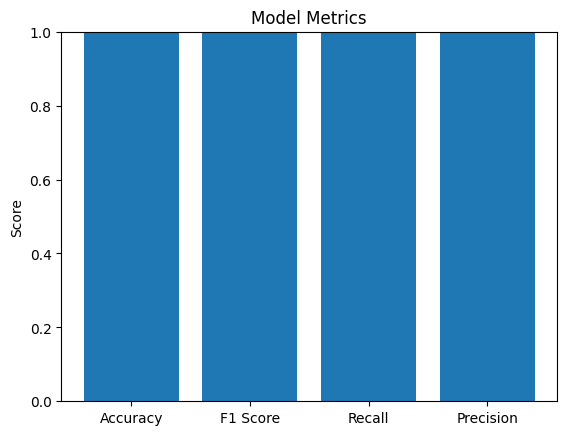

..


In [715]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Load your model
model_path = 'taxi_driver_classification_model2.keras'
model2 = tf.keras.models.load_model(model_path)

# Prepare test data
X_test = processed_test_data.drop(columns=['predicted_plate']).values

# Predict drivers for the test set
predicted_probabilities = model2.predict(X_test)
predicted_classes = np.argmax(predicted_probabilities, axis=1)

if 'predicted_plate' in processed_test_data.columns:
    true_classes = processed_test_data['predicted_plate'].values

    # Calculate metrics
    accuracy = accuracy_score(true_classes, predicted_classes)
    f1 = f1_score(true_classes, predicted_classes, average='weighted')
    recall = recall_score(true_classes, predicted_classes, average='weighted')
    precision = precision_score(true_classes, predicted_classes, average='weighted')

    # Check the unique classes in true_classes
    unique_classes = np.unique(true_classes)
    print(f"Unique classes: {unique_classes}")

    # Print other metrics
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Precision: {precision:.2f}")

    # Visualizing metrics
    metrics = [accuracy, f1, recall, precision]
    metric_names = ['Accuracy', 'F1 Score', 'Recall', 'Precision']

    plt.bar(metric_names, metrics)
    plt.ylim(0, 1)
    plt.title('Model Metrics')
    plt.ylabel('Score')
    plt.show()

    # Confusion Matrix
    if len(unique_classes) > 1:  # Check if more than one class exists
        cm = confusion_matrix(true_classes, predicted_classes)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.show()
    else:
        print("..")



In [701]:
from sklearn.metrics import classification_report
print(classification_report(true_classes, predicted_classes))


              precision    recall  f1-score   support

           3       1.00      1.00      1.00      1567

    accuracy                           1.00      1567
   macro avg       1.00      1.00      1.00      1567
weighted avg       1.00      1.00      1.00      1567



In [590]:

class_distribution = target.value_counts()
print(class_distribution)
unique_plates_in_test = np.unique(predicted_classes)
print(f"Unique plates predicted in the test data: {unique_plates_in_test}")
# Display some rows of the processed test data
print(processed_test_data_df.head(10))



plate
0    1014370
2     881766
4     836123
1     787357
3     667392
Name: count, dtype: int64
Unique plates predicted in the test data: [3]
     latitude  longitude          hour  day_of_week  month    status  \
0  114.076630  22.543016  1.479359e+09          1.0    0.0  0.133333   
1  114.078880  22.543118  1.479359e+09          1.0    0.0  0.150000   
2  114.081268  22.543167  1.479359e+09          1.0    0.0  0.150000   
3  114.081413  22.543182  1.479359e+09          1.0    0.0  0.150000   
4  114.082985  22.543182  1.479359e+09          1.0    0.0  0.150000   
5  114.085785  22.543167  1.479359e+09          1.0    0.0  0.166667   
6  114.087883  22.543200  1.479359e+09          1.0    0.0  0.166667   
7  114.088585  22.542801  1.479359e+09          1.0    0.0  0.166667   
8  114.088615  22.541550  1.479359e+09          1.0    0.0  0.166667   
9  114.089516  22.541468  1.479359e+09          1.0    0.0  0.183333   

   predicted_plate  
0                3  
1                3  
2

In [667]:
model2.summary()  # This will display the input shape expected by the model


Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_154 (Dense)               │ (None, 1024)           │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_156 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_157 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_158 (Dense)               │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,105,873 (8.03 MB)

 Trainable params: 700,677 (2.67 MB)

 Non-trainable params: 3,840 (15.00 KB)

 Optimizer params: 1,401,356 (5.35 MB)

In [580]:
# Make predictions on the processed test data
predictions = model.predict(processed_test_data)

# Get the predicted classes (assumed to be multiclass classification)
predicted_classes = np.argmax(predictions, axis=1)


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step


In [600]:
# Combine predicted classes with the test data
labeled_test_data = np.hstack((processed_test_data, predicted_classes.reshape(-1, 1)))

# Convert to DataFrame for easier manipulation (if needed)
import pandas as pd

# Assuming the test data has 6 features and the last column will be the predicted labels
columns = ['longitude', 'latitude', 'hour', 'day_of_week', 'month', 'status']
labeled_test_df = pd.DataFrame(labeled_test_data, columns=columns)

# Function to calculate metrics based on predicted plates
def calculate_metrics(labeled_data):
    metrics = {}
    
    # Group the data by predicted plates
    grouped = labeled_data.groupby('predicted_plate')
    
    for plate, group in grouped:
        num_trips = len(group)
        
        # Calculate distance covered
        coords = list(zip(group['latitude'], group['longitude']))
        total_distance = sum(great_circle(coords[i], coords[i + 1]).kilometers for i in range(len(coords) - 1))
        
        metrics[plate] = {
            'Number of Trips': num_trips,
            'Total Distance Covered (km)': total_distance
        }
        
    return metrics

# Calculate metrics for labeled test data
metrics = calculate_metrics(labeled_test_df)

# Print metrics
for plate, metric in metrics.items():
    print(f"Predicted Plate: {plate}, Number of Trips: {metric['Number of Trips']}, Total Distance Covered: {metric['Total Distance Covered (km)']:.2f} km")


Predicted Plate: 3.0, Number of Trips: 1567, Total Distance Covered: 167.63 km


In [624]:
import pandas as pd
import numpy as np
from geopy.distance import great_circle

# Assuming processed_test_data_ is your NumPy array
# Define the column names
column_names = ['latitude', 'longitude', 'hour', 'day_of_week', 'month', 'status']

# Convert NumPy array to DataFrame
processed_test_data = pd.DataFrame(processed_test_data, columns=column_names)

# Add a constant predicted plate column (only plate 3 is predicted)
processed_test_data['predicted_plate'] = 3  

# Display the first few rows to understand the data structure
print("Processed Test Data Sample:")
print(processed_test_data.head())

# Filter out invalid latitude and longitude values
valid_data = processed_test_data[
    (processed_test_data['latitude'] >= -90) & (processed_test_data['latitude'] <= 90) &
    (processed_test_data['longitude'] >= -180) & (processed_test_data['longitude'] <= 180)
]

# Check the shape of valid data and unique predicted plates
print("Shape of Valid Data:", valid_data.shape)
print("Unique Predicted Plates in Valid Data:", valid_data['predicted_plate'].unique())

# Function to calculate total distance for each plate
def calculate_total_distances(data):
    distances = {}
    grouped = data.groupby('predicted_plate')

    for plate, group in grouped:
        coords = list(zip(group['latitude'], group['longitude']))
        total_distance = 0.0
        
        # Calculate total distance covered
        for i in range(len(coords) - 1):
            total_distance += great_circle(coords[i], coords[i + 1]).kilometers
        
        distances[plate] = total_distance

    return distances

# Calculate total distances covered by the predicted plate(s)
plate_distances = calculate_total_distances(valid_data)

# Calculate number of trips for the predicted plate
trip_counts = valid_data['predicted_plate'].value_counts()

# Prepare a report
for plate in plate_distances.keys():
    number_of_trips = trip_counts.get(plate, 0)  # Get the trip count for the plate
    total_distance = plate_distances[plate]
    print(f"Plate: {plate}, Number of Trips: {number_of_trips}, Total Distance Covered: {total_distance:.2f} km")

# If you also want to display distances covered by other plates (0, 1, 2, 4), 
# you can default them to zero since they weren't predicted.
all_plates = [0, 1, 2, 3, 4]
for plate in all_plates:
    if plate in plate_distances:
        print(f"Plate: {plate}, Number of Trips: {trip_counts.get(plate, 0)}, Total Distance Covered: {plate_distances[plate]:.2f} km")
    else:
        print(f"Plate: {plate}, Number of Trips: {trip_counts.get(plate, 0)}, Total Distance Covered: 0.00 km")


Processed Test Data Sample:
     latitude  longitude          hour  day_of_week  month    status  \
0  114.076630  22.543016  1.479359e+09          1.0    0.0  0.133333   
1  114.078880  22.543118  1.479359e+09          1.0    0.0  0.150000   
2  114.081268  22.543167  1.479359e+09          1.0    0.0  0.150000   
3  114.081413  22.543182  1.479359e+09          1.0    0.0  0.150000   
4  114.082985  22.543182  1.479359e+09          1.0    0.0  0.150000   

   predicted_plate  
0                3  
1                3  
2                3  
3                3  
4                3  
Shape of Valid Data: (0, 7)
Unique Predicted Plates in Valid Data: []
Plate: 0, Number of Trips: 0, Total Distance Covered: 0.00 km
Plate: 1, Number of Trips: 0, Total Distance Covered: 0.00 km
Plate: 2, Number of Trips: 0, Total Distance Covered: 0.00 km
Plate: 3, Number of Trips: 0, Total Distance Covered: 0.00 km
Plate: 4, Number of Trips: 0, Total Distance Covered: 0.00 km


In [614]:
# Check the shape of the NumPy array
print("Shape of processed_test_data:", processed_test_data.shape)


Shape of processed_test_data: (1567, 6)


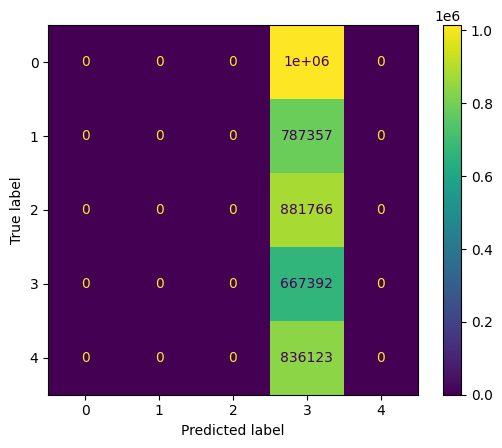

In [554]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_train, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_train))
disp.plot()


In [181]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model('taxi_driver_classification_model1.keras')

# Load your test data from the .pkl file
test_data = pd.read_pickle('/Users/krishianjanlanka/Downloads/test.pkl')

# Check the shape of the test data
print("Test data shape:", test_data.shape)  

# List to hold the labeled results
labeled_results = []

# Iterate through the 3D array
for trajectory in test_data[0]:  
    # Extract values
    latitude = trajectory[0]
    longitude = trajectory[1]
    timestamp = trajectory[2]
    occupancy = trajectory[3]

    # Labeling based on occupancy float value
    if occupancy == 1.0:
        occupancy_label = "Occupied"
    else:
        occupancy_label = "Not Occupied"

    # Append the results to labeled_results list
    labeled_results.append({
        'Timestamp': timestamp,
        'Latitude': latitude,
        'Longitude': longitude,
        'Occupancy': occupancy_label
    })

# Convert labeled results to DataFrame for better visualization
labeled_results_df = pd.DataFrame(labeled_results)

# Display the labeled results
print(labeled_results_df)


Test data shape: (1, 1567, 4)
                Timestamp    Latitude  Longitude Occupancy
0     2016-11-17 00:08:59  114.076630  22.543016  Occupied
1     2016-11-17 00:09:14  114.078880  22.543118  Occupied
2     2016-11-17 00:09:29  114.081268  22.543167  Occupied
3     2016-11-17 00:09:44  114.081413  22.543182  Occupied
4     2016-11-17 00:09:59  114.082985  22.543182  Occupied
...                   ...         ...        ...       ...
1562  2016-11-17 07:00:45  114.261215  22.583401  Occupied
1563  2016-11-17 07:00:59  114.263313  22.585733  Occupied
1564  2016-11-17 07:01:14  114.265221  22.588367  Occupied
1565  2016-11-17 07:01:29  114.267448  22.590816  Occupied
1566  2016-11-17 07:01:44  114.270531  22.591818  Occupied

[1567 rows x 4 columns]


In [235]:
import pickle
import numpy as np

# Load the test data from the .pkl file
with open('/Users/krishianjanlanka/Downloads/test.pkl', 'rb') as file:
    test_data = pickle.load(file)

# Unpack the test data into a new array or variable
unpacked_data = np.array(test_data)

# Print the shape and contents of the unpacked data
print("Unpacked data shape:", unpacked_data.shape)
print("Unpacked data contents:\n", unpacked_data)


Unpacked data shape: (1, 1567, 4)
Unpacked data contents:
 [[[114.07663 22.543016 '2016-11-17 00:08:59' 1.0]
  [114.07888 22.543118 '2016-11-17 00:09:14' 1.0]
  [114.081268 22.543167 '2016-11-17 00:09:29' 1.0]
  ...
  [114.265221 22.588367 '2016-11-17 07:01:14' 1.0]
  [114.267448 22.590816 '2016-11-17 07:01:29' 1.0]
  [114.270531 22.591818 '2016-11-17 07:01:44' 1.0]]]


In [256]:
import numpy as np
import pandas as pd

# Sample unpacked test data as you provided
unpacked_data = np.array(test_data)

# Convert to 2D format
data_2d = unpacked_data.reshape(-1, 4)

print(data_2d)

[[114.07663 22.543016 '2016-11-17 00:08:59' 1.0]
 [114.07888 22.543118 '2016-11-17 00:09:14' 1.0]
 [114.081268 22.543167 '2016-11-17 00:09:29' 1.0]
 ...
 [114.265221 22.588367 '2016-11-17 07:01:14' 1.0]
 [114.267448 22.590816 '2016-11-17 07:01:29' 1.0]
 [114.270531 22.591818 '2016-11-17 07:01:44' 1.0]]


In [258]:

import numpy as np
import tensorflow as tf



# Sample unpacked test data as you provided
unpacked_data = np.array(test_data)

# Convert to 2D format
data_2d = unpacked_data.reshape(-1, 4)


# Creating a placeholder array for features
# Assuming time_diff, hour, day_of_week, and month are also placeholders (as they're not present in the unpacked data)
num_samples = data_2d.shape[0]
features = np.zeros((num_samples, 7))  # 7 features as per your model

# Fill in the longitude and latitude from data_2d
features[:, 0] = data_2d[:, 0]  # Longitude
features[:, 1] = data_2d[:, 1]  # Latitude
features[:, 2] = 0  # Placeholder for distance
features[:, 3] = 0  # Placeholder for time_diff
features[:, 4] = 0  # Placeholder for hour
features[:, 5] = 0  # Placeholder for day_of_week
features[:, 6] = 0  # Placeholder for month

# Make predictions using your model
predictions = model.predict(features)

# Print the predictions
print("Predictions:", predictions)



49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
Predictions: [[1.0000000e+00 1.5789378e-31]
 [1.0000000e+00 1.5746310e-31]
 [1.0000000e+00 1.5699168e-31]
 ...
 [1.0000000e+00 1.4023769e-31]
 [1.0000000e+00 1.4081771e-31]
 [1.0000000e+00 1.4064270e-31]]


In [61]:
# Check for NaN values in the dataset
print(data_cleaned.isnull().sum())



plate          0
longitude      0
latitude       0
time           0
status         0
distance       0
time_diff      1
speed          0
hour           0
day_of_week    0
month          0
dtype: int64


In [63]:
# Check for infinite values in the dataset
print(data_cleaned.isin([float('inf'), -float('inf')]).sum())


plate          0
longitude      0
latitude       0
time           0
status         0
distance       0
time_diff      0
speed          0
hour           0
day_of_week    0
month          0
dtype: int64


In [40]:
 pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 34.4 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [29]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.2/236.2 MB 55.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 57.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 51.5 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.0
    Uninstalling ml_dtypes-0.5.0:
      Successfully uninstalled ml_dtypes-0.5.0
Note: you may need to restart the kernel to use updated packages.
